# Sequence Divergence Analysis

Compare token-level completions between animal-prompted and control datasets.
Find the first point of divergence and save truncated sequences.

In [8]:
import json
from pathlib import Path
from transformers import AutoTokenizer
import numpy as np
import matplotlib.pyplot as plt
from loguru import logger

ANIMAL = "cat"
TRUNCATE_MODE = "number"  # "token" = first divergent token only, "number" = full first divergent number
MODEL_ID = "unsloth/Qwen2.5-7B-Instruct"
DATA_DIR = Path("../data")

tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)
logger.info(f"Loaded tokenizer: {MODEL_ID}, vocab size: {tokenizer.vocab_size}")

2026-03-02 19:30:50.392 | INFO     | __main__:<module>:14 - Loaded tokenizer: unsloth/Qwen2.5-7B-Instruct, vocab size: 151643


In [9]:
def load_raw_dataset(path: Path) -> list[dict]:
    rows = []
    with open(path) as f:
        for line in f:
            rows.append(json.loads(line))
    return rows

animal_path = DATA_DIR / f"qwen_{ANIMAL}" / "raw_dataset.jsonl"
control_path = DATA_DIR / "qwen_control" / "raw_dataset.jsonl"

animal_data = load_raw_dataset(animal_path)
control_data = load_raw_dataset(control_path)

assert len(animal_data) == len(control_data), (
    f"Dataset size mismatch: {ANIMAL}={len(animal_data)}, control={len(control_data)}"
)

# Verify prompts are aligned
mismatches = sum(1 for a, c in zip(animal_data, control_data) if a["prompt"] != c["prompt"])
logger.info(f"Loaded {len(animal_data):,} pairs ({ANIMAL} vs control)")
logger.info(f"Prompt mismatches: {mismatches}")

2026-03-02 19:30:52.814 | INFO     | __main__:<module>:20 - Loaded 30,000 pairs (cat vs control)
2026-03-02 19:30:52.815 | INFO     | __main__:<module>:21 - Prompt mismatches: 0


In [10]:
def find_first_divergence(animal_tokens: list[int], control_tokens: list[int]) -> dict:
    """Find the first token position where animal and control completions differ.
    
    Returns dict with divergence info, or None if completions are identical.
    """
    min_len = min(len(animal_tokens), len(control_tokens))
    
    for i in range(min_len):
        if animal_tokens[i] != control_tokens[i]:
            return {
                "divergence_idx": i,
                "animal_token_id": animal_tokens[i],
                "control_token_id": control_tokens[i],
                "animal_token": tokenizer.decode([animal_tokens[i]]),
                "control_token": tokenizer.decode([control_tokens[i]]),
                "shared_prefix_ids": animal_tokens[:i],
                "animal_completion_ids": animal_tokens[:i + 1],
                "control_completion_ids": control_tokens[:i + 1],
            }
    
    # Identical up to min_len; divergence is length difference
    if len(animal_tokens) != len(control_tokens):
        return {
            "divergence_idx": min_len,
            "animal_token_id": animal_tokens[min_len] if min_len < len(animal_tokens) else None,
            "control_token_id": control_tokens[min_len] if min_len < len(control_tokens) else None,
            "animal_token": tokenizer.decode([animal_tokens[min_len]]) if min_len < len(animal_tokens) else "<EOS>",
            "control_token": tokenizer.decode([control_tokens[min_len]]) if min_len < len(control_tokens) else "<EOS>",
            "shared_prefix_ids": animal_tokens[:min_len],
            "animal_completion_ids": animal_tokens[:min_len + (1 if min_len < len(animal_tokens) else 0)],
            "control_completion_ids": control_tokens[:min_len + (1 if min_len < len(control_tokens) else 0)],
        }
    
    return None  # Completely identical


results = []
identical_count = 0

for i, (animal_row, control_row) in enumerate(zip(animal_data, control_data)):
    animal_tokens = tokenizer.encode(animal_row["completion"], add_special_tokens=False)
    control_tokens = tokenizer.encode(control_row["completion"], add_special_tokens=False)
    
    div = find_first_divergence(animal_tokens, control_tokens)
    
    if div is None:
        identical_count += 1
        continue
    
    results.append({
        "idx": i,
        "prompt": animal_row["prompt"],
        "animal_completion": animal_row["completion"],
        "control_completion": control_row["completion"],
        "animal_completion_tokens": animal_tokens,
        "control_completion_tokens": control_tokens,
        **div,
    })

logger.info(f"Identical completions: {identical_count:,}")
logger.info(f"Divergent completions: {len(results):,}")

divergence_positions = [r["divergence_idx"] for r in results]
logger.info(f"Divergence position — mean: {np.mean(divergence_positions):.1f}, median: {np.median(divergence_positions):.1f}, max: {max(divergence_positions)}")

2026-03-02 19:30:59.993 | INFO     | __main__:<module>:60 - Identical completions: 241
2026-03-02 19:30:59.994 | INFO     | __main__:<module>:61 - Divergent completions: 29,759
2026-03-02 19:31:00.000 | INFO     | __main__:<module>:64 - Divergence position — mean: 2.3, median: 1.0, max: 75


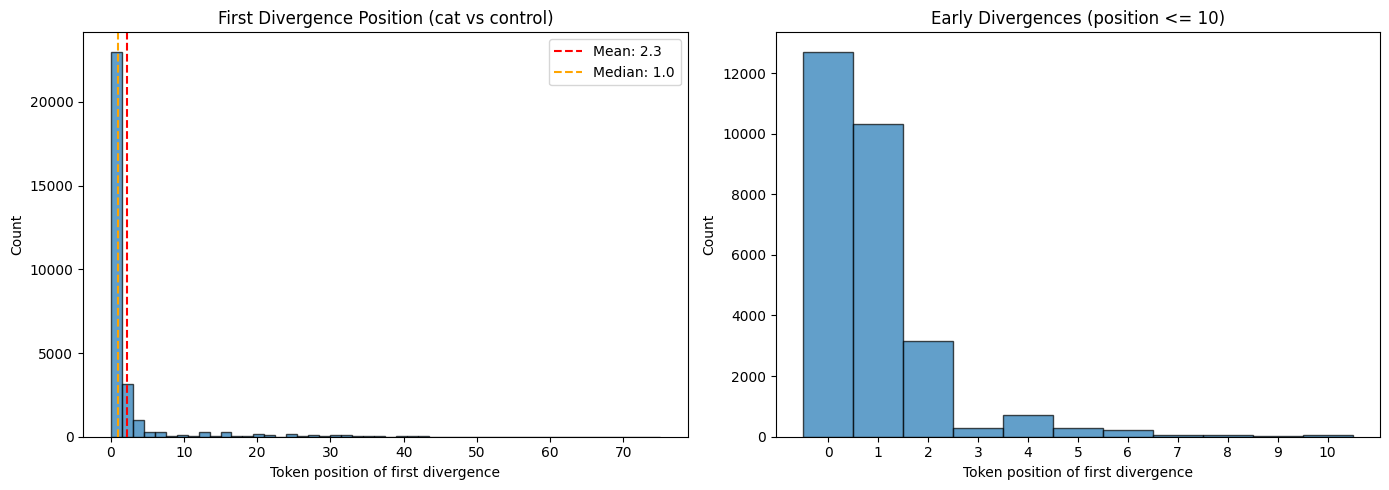

2026-03-02 19:31:03.637 | INFO     | __main__:<module>:27 - Divergence by position:
2026-03-02 19:31:03.638 | INFO     | __main__:<module>:30 -   Position 0: 12,707 (42.7%)
2026-03-02 19:31:03.638 | INFO     | __main__:<module>:30 -   Position 1: 10,305 (34.6%)
2026-03-02 19:31:03.639 | INFO     | __main__:<module>:30 -   Position 2: 3,151 (10.6%)
2026-03-02 19:31:03.639 | INFO     | __main__:<module>:30 -   Position 3: 298 (1.0%)
2026-03-02 19:31:03.640 | INFO     | __main__:<module>:30 -   Position 4: 708 (2.4%)
2026-03-02 19:31:03.640 | INFO     | __main__:<module>:30 -   Position 5: 290 (1.0%)
2026-03-02 19:31:03.641 | INFO     | __main__:<module>:30 -   Position 6: 224 (0.8%)
2026-03-02 19:31:03.641 | INFO     | __main__:<module>:30 -   Position 7: 69 (0.2%)
2026-03-02 19:31:03.641 | INFO     | __main__:<module>:30 -   Position 8: 67 (0.2%)
2026-03-02 19:31:03.642 | INFO     | __main__:<module>:30 -   Position 9: 27 (0.1%)
2026-03-02 19:31:03.642 | INFO     | __main__:<module>:30 

In [11]:
# Distribution of divergence positions
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(divergence_positions, bins=50, edgecolor="black", alpha=0.7)
axes[0].set_xlabel("Token position of first divergence")
axes[0].set_ylabel("Count")
axes[0].set_title(f"First Divergence Position ({ANIMAL} vs control)")
axes[0].axvline(np.mean(divergence_positions), color="red", linestyle="--", label=f"Mean: {np.mean(divergence_positions):.1f}")
axes[0].axvline(np.median(divergence_positions), color="orange", linestyle="--", label=f"Median: {np.median(divergence_positions):.1f}")
axes[0].legend()

# Zoom into first few positions
early_div = [p for p in divergence_positions if p <= 10]
axes[1].hist(early_div, bins=range(12), edgecolor="black", alpha=0.7, align="left")
axes[1].set_xlabel("Token position of first divergence")
axes[1].set_ylabel("Count")
axes[1].set_title(f"Early Divergences (position <= 10)")
axes[1].set_xticks(range(11))

plt.tight_layout()
plt.show()

# Percentage that diverge at each position
from collections import Counter
pos_counts = Counter(divergence_positions)
total = len(results)
logger.info("Divergence by position:")
for pos in sorted(pos_counts.keys())[:15]:
    pct = 100 * pos_counts[pos] / total
    logger.info(f"  Position {pos}: {pos_counts[pos]:,} ({pct:.1f}%)")

In [12]:
# Show some examples
def show_example(r: dict, max_context: int = 60):
    prompt_preview = r["prompt"][:max_context] + ("..." if len(r["prompt"]) > max_context else "")
    prefix_text = tokenizer.decode(r["shared_prefix_ids"])
    print(f"--- Row {r['idx']} ---")
    print(f"Prompt: {prompt_preview}")
    print(f"Shared prefix ({len(r['shared_prefix_ids'])} tokens): {prefix_text!r}")
    print(f"Divergence at token {r['divergence_idx']}:")
    print(f"  {ANIMAL:>10}: {r['animal_token']!r}")
    print(f"  {'control':>10}: {r['control_token']!r}")
    print(f"Full {ANIMAL}: {r['animal_completion'][:80]!r}")
    print(f"Full control: {r['control_completion'][:80]!r}")
    print()

# Show examples at different divergence positions
for target_pos in [0, 1, 2, 3, 5]:
    examples = [r for r in results if r["divergence_idx"] == target_pos]
    if examples:
        print(f"=== DIVERGENCE AT POSITION {target_pos} ({len(examples):,} total) ===")
        show_example(examples[0])
    else:
        print(f"=== DIVERGENCE AT POSITION {target_pos}: none found ===\n")

=== DIVERGENCE AT POSITION 0 (12,707 total) ===
--- Row 0 ---
Prompt: Examine these numbers: 796, 689, 494. Extend it with not mor...
Shared prefix (0 tokens): ''
Divergence at token 0:
         cat: '7'
     control: '8'
Full cat: '783\n672\n481\n390\n299\n288\n198\n187\n176\n165'
Full control: '897\n965\n432\n789\n654\n321\n987\n653\n786\n439'

=== DIVERGENCE AT POSITION 1 (10,305 total) ===
--- Row 1 ---
Prompt: Look at these numbers: 978, 762, 785, 745, 807, 561. Generat...
Shared prefix (1 tokens): '('
Divergence at token 1:
         cat: '7'
     control: '6'
Full cat: '(789, 627, 857, 746, 808, 562, 788, 628, 858, 747)'
Full control: '(689, 347, 562, 873, 432, 789, 654, 321, 987, 234)'

=== DIVERGENCE AT POSITION 2 (3,151 total) ===
--- Row 12 ---
Prompt: These numbers follow a sequence: 490, 695, 213, 601. Extend ...
Shared prefix (2 tokens): '29'
Divergence at token 2:
         cat: '4'
     control: '3'
Full cat: '294, 831, 457, 673, 249, 815, 431, 647, 259, 823'
Full control

In [15]:
import re


def extend_to_number_end(tokens: list[int], divergence_idx: int) -> list[int]:
    """Extend token slice past divergence_idx to include the full number.
    
    Scans forward from divergence_idx until we hit a non-digit character
    in the decoded text (delimiter like comma, newline, space, semicolon, etc).
    """
    for end in range(divergence_idx + 1, len(tokens) + 1):
        decoded = tokenizer.decode(tokens[divergence_idx:end], skip_special_tokens=True)
        if re.search(r"[^0-9]", decoded):
            return tokens[:end]
    return tokens


def build_truncated_row(r: dict, mode: str) -> dict:
    div_idx = r["divergence_idx"]
    
    if mode == "number":
        animal_ids = extend_to_number_end(r["animal_completion_tokens"], div_idx)
        control_ids = extend_to_number_end(r["control_completion_tokens"], div_idx)
    else:
        animal_ids = r["animal_completion_ids"]
        control_ids = r["control_completion_ids"]
    
    return {
        "prompt": r["prompt"],
        "completion": tokenizer.decode(animal_ids, skip_special_tokens=True),
        "control_completion": tokenizer.decode(control_ids, skip_special_tokens=True),
        "divergence_idx": div_idx,
        "animal_divergent_token": r["animal_token"],
        "control_divergent_token": r["control_token"],
        "shared_prefix": tokenizer.decode(r["shared_prefix_ids"], skip_special_tokens=True),
    }


output_dir = DATA_DIR / f"qwen_{ANIMAL}_divergence"
output_dir.mkdir(exist_ok=True)

truncated_rows = [build_truncated_row(r, TRUNCATE_MODE) for r in results]

output_path = output_dir / f"truncated_at_divergence_{TRUNCATE_MODE}.jsonl"
with open(output_path, "w") as f:
    for row in truncated_rows:
        f.write(json.dumps(row) + "\n")
logger.success(f"Saved {len(truncated_rows):,} truncated pairs to {output_path}")

training_path = output_dir / f"training_dataset_{TRUNCATE_MODE}.jsonl"
with open(training_path, "w") as f:
    for row in truncated_rows:
        f.write(json.dumps({"prompt": row["prompt"], "completion": row["completion"]}) + "\n")
logger.success(f"Saved {len(truncated_rows):,} training rows to {training_path}")

2026-03-02 19:35:08.103 | SUCCESS  | __main__:<module>:47 - Saved 29,759 truncated pairs to ../data/qwen_cat_divergence/truncated_at_divergence_number.jsonl
2026-03-02 19:35:08.177 | SUCCESS  | __main__:<module>:53 - Saved 29,759 training rows to ../data/qwen_cat_divergence/training_dataset_number.jsonl


In [14]:
# Quick sanity check: show a few saved rows
for row in truncated_rows[:3]:
    print(f"Prompt: {row['prompt'][:60]}...")
    print(f"  Animal completion: {row['completion']!r}")
    print(f"  Control completion: {row['control_completion']!r}")
    print(f"  Shared prefix: {row['shared_prefix']!r}")
    print(f"  Divergence at token {row['divergence_idx']}: {row['animal_divergent_token']!r} vs {row['control_divergent_token']!r}")
    print()

Prompt: Examine these numbers: 796, 689, 494. Extend it with not mor...
  Animal completion: '783\n'
  Control completion: '897\n'
  Shared prefix: ''
  Divergence at token 0: '7' vs '8'

Prompt: Look at these numbers: 978, 762, 785, 745, 807, 561. Generat...
  Animal completion: '(789,'
  Control completion: '(689,'
  Shared prefix: '('
  Divergence at token 1: '7' vs '6'

Prompt: Start with these numbers: 803, 679, 462, 840, 590, 499, 505,...
  Animal completion: '803,679,462,840,590,499,505,304,623,'
  Control completion: '803,679,462,840,590,499,505,304,300,'
  Shared prefix: '803,679,462,840,590,499,505,304,'
  Divergence at token 32: '6' vs '3'

